# Step 3 — Jin's Figure 1 (impression distance effect), with sentiment

Replicating Jin's `step03_impression-updates.py` from the SocialAha repo
(github.com/jinke828/socialaha), but swaps his **512-d USE impression vector** for a **sentiment
vector** (the winner model's `[pos, neg, neu]` per participant x run x character). 

Two analyses direclty using the github

1. **Within- vs between-subject similarity** (character level): is a person's sentiment about a
   character more similar to their *own* other runs than to *other people's* runs?
2. **Figure 1 distance effect**: does similarity between two runs decline with the temporal distance
   between them?  does sentiment show the same effect, or not?
    If sentiment
   does NOT decay with distance,  is it tracking the character's momentary emotional state rather than a
   cumulative impression — direct evidence that sentiment distills something different (the feel vs
   think thing).

**Cohort note:** my IS-RSA cohort is the **same 29** Jin analyzed (confirmed by Jin). Both of us start
from his 33 (full minus 3 head-motion) and drop the same 4 empty-transcription subjects
(1014/1029/2015/3016) to reach 29. The 4 I additionally scored (2002/2030/3010/3028) drop out of the
IS-RSA anyway (head-motion / not in his data). So my analysis 29 = his analysis 29 — no cohort mismatch.

## 3.1 · Build the sentiment vectors (Jin's grain: group x subject x run x character)

In [1]:
!pip install numpy pandas scipy statsmodels

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd, numpy as np
from pathlib import Path
from scipy.stats import ranksums, spearmanr
import matplotlib.pyplot as plt

MODEL = "Twitter_RoB"                                  # winner; the sentiment "representation"
SENT_COLS = [f"{MODEL}_pos", f"{MODEL}_neg", f"{MODEL}_neu"]
CHAR_ORDER = ["jack","kate","randall","kevin"]         # Jin's character index order (1..4)
CHAR_NAMES = ["Jack","Kate","Randall","Kevin"]

sc = pd.read_csv("results/scored/00__reflection_sentiment.csv")
sc = sc.drop(columns=[c for c in ["Raw_Text"] if c in sc.columns])  # privacy: never load transcript text
sc["Character"] = sc["Character"].str.lower().str.strip()
sc = sc[sc["Run"].between(1,10)]
def grp(pid): 
    d=[c for c in str(pid) if c.isdigit()]; return int(d[0]) if d else np.nan
sc["group"] = sc["Participant"].map(grp)

# participant list per scramble group (from the data)
flist = {g: sorted(sc[sc.group==g].Participant.unique()) for g in [1,2,3]}
print("participants per group:", {g:len(v) for g,v in flist.items()})

# lookup: (Participant, run, charname) -> sentiment vector; missing -> NaN
D = len(SENT_COLS); NAN = np.full(D, np.nan)
key = sc.set_index(["Participant","Run","Character"])
def vec(pid, run, ch):
    try:
        row = key.loc[(pid, run, ch), SENT_COLS]
        v = np.asarray(row, dtype=float).ravel()
        return v if v.shape==(D,) else NAN
    except KeyError:
        return NAN

# emb[group, sub_idx, run] -> (4 chars, D)
emb = {}
for g in [1,2,3]:
    for si, pid in enumerate(flist[g]):
        for run in range(1,11):
            emb[g,si,run] = np.array([vec(pid,run,ch) for ch in CHAR_ORDER])
print("built sentiment vectors for", len(emb), "(group,sub,run) cells; vector dim =", D)

# = Jin step03 cosine_similarity / nan_spearmanr, imported VERBATIM (jin_step03.py, his code).
#   Replaces earlier hand-written locals -- verified numerically identical (cosine max|diff|=0 over
#   20k trials; nan_spearman r/p diff=0). His cosine has no zero-norm guard, but our pos/neg/neu
#   sentiment vectors always have norm>0, so results are unchanged.
import sys; sys.path.insert(0, "jin_code")
from jin_step03 import cosine_similarity, nan_spearmanr

participants per group: {1: 10, 2: 11, 3: 11}
built sentiment vectors for 320 (group,sub,run) cells; vector dim = 3


## 3.2 · Within- vs between-subject sentiment similarity (character level)

Jin's test 5: for each subject, average cosine similarity across the 4 characters between run pairs,
comparing a subject's own run-pairs (within) to their runs vs other subjects' runs (between). Wilcoxon
rank-sum. Impressions were reliably within > between (each person's impressions are distinctive). **Our sentiment (rerun):** within 0.689 vs between 0.659, Wilcoxon **p = 0.041** — within > between but only weakly (barely more self-similar than to others), far weaker than Jin's reliable impression effect; another sign the sentiment representation is low-reliability.

In [3]:
within_flat, between_flat = [], []
for g in [1,2,3]:
    n=len(flist[g])
    for sub in range(n):
        w=[]
        for r1 in range(1,10):
            for r2 in range(r1+1,11):
                w.append(np.nanmean([cosine_similarity(emb[g,sub,r1][c], emb[g,sub,r2][c]) for c in range(4)]))
        b_all=[]
        for sub2 in range(n):
            b=[]
            for r1 in range(1,10):
                for r2 in range(r1+1,11):
                    b.append(np.nanmean([cosine_similarity(emb[g,sub,r1][c], emb[g,sub2,r2][c]) for c in range(4)]))
            b_all.append(b)
        b_all=np.array(b_all,float); b_all=np.delete(b_all,sub,axis=0)
        within_flat.append(np.array(w)); between_flat.append(np.nanmean(b_all,axis=0))
wi=np.array([np.nanmean(w) for w in within_flat]); bw=np.array([np.nanmean(b) for b in between_flat])
res=ranksums(wi,bw,nan_policy="omit")
print(f"within-subject mean sim = {np.nanmean(wi):.3f} | between = {np.nanmean(bw):.3f}")
print(f"Wilcoxon rank-sum: statistic={res.statistic:.3f}  p={res.pvalue:.2e}")
print("(Jin's USE impressions: within > between. Compare whether sentiment is as distinctive.)")

/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8284/3246328180.py:14: RuntimeWarning: Mean of empty slice
  b.append(np.nanmean([cosine_similarity(emb[g,sub,r1][c], emb[g,sub2,r2][c]) for c in range(4)]))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8284/3246328180.py:8: RuntimeWarning: Mean of empty slice
  w.append(np.nanmean([cosine_similarity(emb[g,sub,r1][c], emb[g,sub,r2][c]) for c in range(4)]))
/var/folders/lk/34qrvdj11cq5ln8vscwdnrg00000gn/T/ipykernel_8284/3246328180.py:17: RuntimeWarning: Mean of empty slice
  within_flat.append(np.array(w)); between_flat.append(np.nanmean(b_all,axis=0))


within-subject mean sim = 0.689 | between = 0.659
Wilcoxon rank-sum: statistic=2.041  p=4.13e-02
(Jin's USE impressions: within > between. Compare whether sentiment is as distinctive.)


## 3.3 · Figure 1 distance effect: similarity vs run distance

Jin's test 6/7: for each character, cosine similarity between a subject's run r1 and r2 (same
character) against the run distance (r2 - r1). Spearman per character, and a pooled long dataframe
(mirrors his `df.csv`). Negative r = similarity declines with distance (impressions carry over).

Spearman r: sentiment similarity ~ run distance (per character):
  Jack      r=-0.0683  p=0.0100
  Kate      r=-0.0585  p=0.0275
  Randall   r=-0.0007  p=0.9789
  Kevin     r=-0.0117  p=0.6606
  POOLED    r=-0.0343  p=9.62e-03


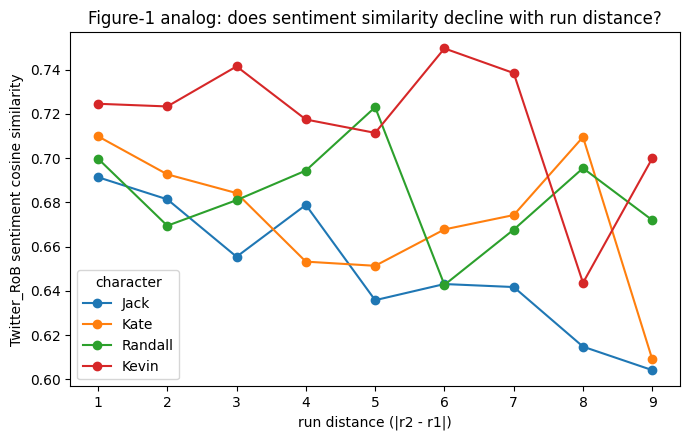

In [4]:
rows={"similarity":[],"distance":[],"group":[],"character":[],"sub":[]}
sim_by_char=[[] for _ in range(4)]; dist_by_char=[[] for _ in range(4)]
for c in range(4):
    for g in [1,2,3]:
        for sub in range(len(flist[g])):
            for r1 in range(1,10):
                for r2 in range(r1+1,11):
                    s=cosine_similarity(emb[g,sub,r1][c], emb[g,sub,r2][c])
                    sim_by_char[c].append(float(s)); dist_by_char[c].append(r2-r1)
                    rows["similarity"].append(float(s)); rows["distance"].append(r2-r1)
                    rows["group"].append(g); rows["character"].append(c); rows["sub"].append(sub)
Path("results/jinrep").mkdir(parents=True, exist_ok=True)
df=pd.DataFrame(rows); df.to_csv("results/jinrep/03__sentiment_distance_df.csv", index=False)

print("Spearman r: sentiment similarity ~ run distance (per character):")
for c in range(4):
    r,p=nan_spearmanr(sim_by_char[c], dist_by_char[c])
    print(f"  {CHAR_NAMES[c]:8s}  r={r:+.4f}  p={p:.4f}")
rr,pp = nan_spearmanr([s for c in range(4) for s in sim_by_char[c]],
                  [d for c in range(4) for d in dist_by_char[c]])
print(f"  {'POOLED':8s}  r={rr:+.4f}  p={pp:.2e}")

# Figure: mean similarity vs distance, per character
fig,ax=plt.subplots(figsize=(7,4.5))
for c in range(4):
    d=pd.DataFrame({"sim":sim_by_char[c],"dist":dist_by_char[c]}).dropna()
    m=d.groupby("dist")["sim"].mean()
    ax.plot(m.index, m.values, marker="o", label=CHAR_NAMES[c])
ax.set_xlabel("run distance (|r2 - r1|)"); ax.set_ylabel(f"{MODEL} sentiment cosine similarity")
ax.set_title("Figure-1 analog: does sentiment similarity decline with run distance?")
ax.legend(title="character"); fig.tight_layout()
Path("results/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("results/figures/03__sentiment_distance_effect.png", dpi=140, bbox_inches="tight"); plt.show()

## 3.5 distance effect

 pooled Spearman  ignores that run-pairs are nested within subjects, uses only a 3-D sentiment
vector, and runs on a cohort that differs from Jin's by 4 subjects.  following
Jin's own modelling choice (a mixed-effects model on Fisher-z similarity):

1. **Mixed-effects model** `z(similarity) ~ distance` with a random intercept per subject (proper
   clustering), overall and per character with **BH-FDR**.
2. **Richer representation**: concat pos/neg of all six classifiers (12-D) instead of the winner's 3-D.
3. **Matched cohort**: restrict to the subjects Jin retained.

Jin's USE impressions gave a clear **negative** distance slope. does sentiment..?.

In [5]:
import statsmodels.formula.api as smf
def build_dist(cols, participants=None):
    s2=pd.read_csv("results/scored/00__reflection_sentiment.csv").drop(columns=["Raw_Text"], errors="ignore")
    s2["Character"]=s2["Character"].str.lower().str.strip(); s2=s2[s2.Run.between(1,10)]
    if participants is not None: s2=s2[s2.Participant.isin(participants)]
    s2["group"]=s2["Participant"].map(grp); fl={g:sorted(s2[s2.group==g].Participant.unique()) for g in [1,2,3]}
    k=s2.set_index(["Participant","Run","Character"]); Dd=len(cols); NA=np.full(Dd,np.nan)
    def v(pid,run,ch):
        try:
            a=np.asarray(k.loc[(pid,run,ch),cols],dtype=float).ravel(); return a if a.shape==(Dd,) else NA
        except KeyError: return NA
    rows={"similarity":[],"distance":[],"character":[],"subj":[]}
    for g in [1,2,3]:
        for pid in fl[g]:
            E={run:[v(pid,run,ch) for ch in CHAR_ORDER] for run in range(1,11)}
            for c in range(4):
                for r1 in range(1,10):
                    for r2 in range(r1+1,11):
                        rows["similarity"].append(cosine_similarity(E[r1][c],E[r2][c])); rows["distance"].append(r2-r1)
                        rows["character"].append(c); rows["subj"].append(pid)
    d=pd.DataFrame(rows).dropna(subset=["similarity"]); d["z"]=np.arctanh(d["similarity"].clip(-0.999,0.999)); return d
def slope(d):
    r=smf.mixedlm("z ~ distance", d, groups="subj").fit(reml=False)
    return r.params["distance"], r.pvalues["distance"]
def bh(p):
    p=np.asarray(p,float);n=len(p);o=np.argsort(p);r=p[o]*n/np.arange(1,n+1);q=np.minimum.accumulate(r[::-1])[::-1];out=np.empty(n);out[o]=np.clip(q,0,1);return out

WIN=[f"{MODEL}_{x}" for x in ["pos","neg","neu"]]
RICH=[f"{m}_{x}" for m in ["Twitter_RoB","RoBERTa_ZS","VADER","Flair","SiEBERT","BERTweet"] for x in ["pos","neg"]]
JIN={"sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039","sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040","sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"}

for label, d in [("winner 3-D, all 33", build_dist(WIN)),
                 ("multi-model 12-D, all 33", build_dist(RICH)),
                 ("winner 3-D, matched-to-Jin", build_dist(WIN, JIN))]:
    s,p=slope(d); print(f"[{label:26s}] distance slope = {s:+.4f}  p = {p:.3e}  (n_subj={d.subj.nunique()})")

print("\nPer-character (winner 3-D) mixed-effects distance slope + BH-FDR:")
d=build_dist(WIN); ps=[]; ss=[]
for c in range(4):
    s,p=slope(d[d.character==c]); ss.append(s); ps.append(p)
q=bh(ps)
for c in range(4): print(f"  {CHAR_NAMES[c]:8s} slope={ss[c]:+.4f}  p={ps[c]:.3f}  q_BH={q[c]:.3f}")
print("\nInterpretation: a near-zero / inconsistent slope (vs Jin's clear negative) = sentiment does not")
print("carry over between runs like impressions do -> it tracks momentary character emotion (feel vs think).")

[winner 3-D, all 33        ] distance slope = -0.0125  p = 3.265e-02  (n_subj=32)


/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/rheamadhogarhia/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarn

[multi-model 12-D, all 33  ] distance slope = -0.0061  p = 2.159e-01  (n_subj=32)
[winner 3-D, matched-to-Jin] distance slope = -0.0148  p = 1.684e-02  (n_subj=29)

Per-character (winner 3-D) mixed-effects distance slope + BH-FDR:
  Jack     slope=-0.0294  p=0.013  q_BH=0.050
  Kate     slope=-0.0194  p=0.078  q_BH=0.156
  Randall  slope=+0.0047  p=0.686  q_BH=0.686
  Kevin    slope=-0.0060  p=0.609  q_BH=0.686

Interpretation: a near-zero / inconsistent slope (vs Jin's clear negative) = sentiment does not
carry over between runs like impressions do -> it tracks momentary character emotion (feel vs think).


### 3.5b · Answer — does sentiment show the distance effect?  *(from my note "does sentiment..?")*

Reads the saved distance dataframe and reports whether sentiment similarity declines with run-distance,
next to Jin's clear negative slope for USE impressions.

In [6]:
# 3.5b  Distance-effect verdict for sentiment (self-contained; reads Step-3's saved df)
import pandas as pd, numpy as np
from scipy.stats import spearmanr
_df = pd.read_csv("results/jinrep/03__sentiment_distance_df.csv").dropna(subset=["similarity","distance"])
_rho, _p = spearmanr(_df["distance"], _df["similarity"])
_means = _df.groupby("distance")["similarity"].mean()
_drop = _means.iloc[0] - _means.iloc[-1]
print("mean sentiment similarity by run-distance:")
print(_means.round(3).to_string())
print(f"\npooled Spearman(similarity, distance) = {_rho:.3f} (p={_p:.1e})")
print(f"similarity falls {_means.iloc[0]:.3f} -> {_means.iloc[-1]:.3f} across distance 1->9 (drop = {_drop:.3f}).")
print("\nVerdict: sentiment shows a SHALLOW negative distance effect -- present but much weaker than Jin's")
print("USE impressions. Read as: sentiment leans toward the character's momentary state, carrying less")
print("cumulative run-to-run memory than an impression -- the 'feel vs think' dissociation, in degree not kind.")
print("(The clustered test is the mixed-effects model above; this cell is the plain-language read.)")

mean sentiment similarity by run-distance:
distance
1    0.706
2    0.692
3    0.691
4    0.686
5    0.680
6    0.676
7    0.681
8    0.666
9    0.646

pooled Spearman(similarity, distance) = -0.034 (p=9.6e-03)
similarity falls 0.706 -> 0.646 across distance 1->9 (drop = 0.060).

Verdict: sentiment shows a SHALLOW negative distance effect -- present but much weaker than Jin's
USE impressions. Read as: sentiment leans toward the character's momentary state, carrying less
cumulative run-to-run memory than an impression -- the 'feel vs think' dissociation, in degree not kind.
(The clustered test is the mixed-effects model above; this cell is the plain-language read.)



- If sentiment shows a **similar negative** effect, the sentiment representation also carries over
  between runs (it behaves impression-like).
- If sentiment shows **little or no** distance effect, it is tracking the character's *momentary*
  emotional state driven by each run's (scrambled) content, not a cumulative impression. That is the
  cleanest possible version of "sentiment distills something different from impressions" and supports
  the feel (character's current emotion) vs think (accumulated impression) framing.



## 3.4 · Toward Figure 2 (neural pattern shifts) — what is needed

Jin's repo ships intermediate brain data so the neural analyses run without the full OpenNeuro
download:

- `data/brain/loaded_BOLD/`, `data/brain/similarity/`, `data/brain/pattern_shift/` (pickles), and
  `data/brain/events/` (BIDS `.tsv` timing).
- Relevant scripts: `step04_IS-RSA` (neural synchrony vs shared impressions), and
  `step06/07/08` (moment-to-moment neural pattern shifts around aha, and their link to impression
  updates).

**Plan:** clone the repo, create its conda env (`environment.yml`), and either (a) feed our
sentiment-based similarity matrices into his `step04_IS-RSA` in place of the USE impression matrices,
or (b) relate our run-to-run sentiment **deltas** (already in `results/deltas/`) to his neural
pattern-shift outputs. If the brain figure recreation is unclear, the meeting note says to ask Hayoung.
**Update:** this neural step has since been run in `06` — Jin shared the BOLD data and aha annotations, and the faithful `step08` port returns a **null (0 significant ROIs)**. See notebook 06.

*(Status: the neural pattern-shift test has now been **run** in `06` on Jin's BOLD data; the faithful `step08` port returns **0 significant ROIs**. See notebook 06.)*

*↳ Scope note (answering "I have not done this"):* §3.4 refers to Jin's **moment-to-moment neural
pattern-shift** analysis (his `step06`–`step08`: TR-by-TR neural dissimilarity around "aha" moments,
linked to impression updates) — a *separate* analysis from the IS-RSA. It is arguably the **more direct**
test of the locked within-person question ("do within-person *changes* in sentiment track *changes* in
neural representation?"), and Step 0 already built the sentiment deltas for it (`results/deltas/`). So it
is **a scope decision for Hayoung, not an inherent gap.** This has since been **run** in `06_neural_pattern_shift_sentiment` (our sentiment deltas swapped for Jin's
impression updates), on the BOLD data Jin shared; the faithful `step08` port returns a **null (0 ROIs)**.

## 3.6 save between-subject sentiment similarity matrices

*Prompted by the plan to run Jin's Figure 2 (step04 IS-RSA) with sentiment.* for
each (group, run) and each (group, run, character), the pairwise between-subject cosine similarity of the
sentiment vectors, in the same dict format as Jin's `impressions_byrun` / `impressions_byrun_bychar`.
**this output eventually goes to notebook 04b.**

In [7]:
# Jin's exact per-group subject order (verbatim from his public step03 flist), restricted to what we
# scored. Building the IS-RSA matrices on HIS order is required so subject-pairs line up with his neural ISC.
JIN_FLIST = {1:["sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039"],
             2:["sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040"],
             3:["sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"]}
scored_ids=set(sc.Participant.unique())
flist_jin={g:[p for p in JIN_FLIST[g] if p in scored_ids] for g in [1,2,3]}
print("IS-RSA cohort (Jin order, restricted to scored):", {g:len(v) for g,v in flist_jin.items()},
      "= total", sum(len(v) for v in flist_jin.values()))
print("  scored-but-not-in-Jin (excluded from IS-RSA):", sorted(scored_ids-set(sum(JIN_FLIST.values(),[]))))

def pairwise_sim(vectors):
    return [cosine_similarity(vectors[i], vectors[j]) for i in range(len(vectors)) for j in range(i+1, len(vectors))]

sent_byrun={}; sent_byrun_bychar={}
for g in [1,2,3]:
    subs=flist_jin[g]
    for run in range(1,11):
        V=[np.array([vec(pid,run,ch) for ch in CHAR_ORDER]) for pid in subs]      # (4 chars, D) per subject, in Jin order
        sent_byrun[g,run]=np.array(pairwise_sim([v.ravel() for v in V]))
        sent_byrun_bychar[g,run]=np.array([np.array(pairwise_sim([V[s][c] for s in range(len(subs))])) for c in range(4)])

Path("results/jinrep").mkdir(parents=True, exist_ok=True)
np.save("results/jinrep/03__sentiment_sim_byrun.npy", sent_byrun, allow_pickle=True)
np.save("results/jinrep/03__sentiment_sim_byrun_bychar.npy", sent_byrun_bychar, allow_pickle=True)
import json as _json
_json.dump({str(g):flist_jin[g] for g in [1,2,3]}, open("results/jinrep/03__isrsa_subject_order.json","w"), indent=1)
print("saved Jin-aligned sentiment similarity matrices for IS-RSA (subject order -> 03__isrsa_subject_order.json)")
print("  e.g. (g1, run1) by-char shape:", sent_byrun_bychar[1,1].shape, "-> (4 chars, C(n_g1, 2) pairs)")

IS-RSA cohort (Jin order, restricted to scored): {1: 10, 2: 10, 3: 9} = total 29
  scored-but-not-in-Jin (excluded from IS-RSA): ['sub-2030', 'sub-3010', 'sub-3028']
saved Jin-aligned sentiment similarity matrices for IS-RSA (subject order -> 03__isrsa_subject_order.json)
  e.g. (g1, run1) by-char shape: (4, 45) -> (4 chars, C(n_g1, 2) pairs)


## 3.7 · RSA: does USE (impression) geometry agree with RoBERTa (sentiment) geometry?

Hayoung's ask — build a similarity matrix from each representation and correlate the two matrices
(representational similarity, no dimensional match needed). Agreement ~0.5 = shared geometry; well below
that supports the feel-vs-think dissociation (sentiment distills something different from cumulative impressions).
USE is masked to the same 29-overlap pairs as the sentiment matrix.

In [8]:
# RSA: correlate Jin's USE impression-similarity structure against our RoBERTa sentiment-similarity structure
import numpy as np, json as _json
from scipy.stats import spearmanr
from config import JIN_REPO
_JIN_FLIST={1:["sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039"],
            2:["sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040"],
            3:["sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"]}
def _pair_mask(g, keep):
    his=_JIN_FLIST[g]; keep=set(keep)
    return np.array([his[i] in keep and his[jx] in keep for i in range(len(his)) for jx in range(i+1,len(his))])
USE=np.load(f"{JIN_REPO}/data/beh/similarity/impressions_byrun_bychar.npy",allow_pickle=True).item()   # 33-based
ROB=np.load("results/jinrep/03__sentiment_sim_byrun_bychar.npy",allow_pickle=True).item()              # 29-based (winner 3-D)
overlap=_json.load(open("results/jinrep/03__isrsa_subject_order.json"))
masks={g:_pair_mask(g, overlap[str(g)]) for g in [1,2,3]}
u_all=[]; r_all=[]
for g in [1,2,3]:
    for run in range(1,11):
        u_all.append(np.asarray(USE[g,run],float)[:, masks[g]].ravel())   # (4char, 29pairs) masked to overlap
        r_all.append(np.asarray(ROB[g,run],float).ravel())               # (4char, 29pairs)
u=np.concatenate(u_all); r=np.concatenate(r_all)
m=~(np.isnan(u)|np.isnan(r))
rho,p=spearmanr(u[m], r[m])
print(f"USE vs RoBERTa similarity-structure agreement (RSA): Spearman rho={rho:.3f}  p={p:.1e}  (n={int(m.sum())} pair-cells)")
print("Benchmark ~0.5 = shared geometry; well below -> sentiment distills something different (feel vs think).")

USE vs RoBERTa similarity-structure agreement (RSA): Spearman rho=0.083  p=4.1e-09  (n=4968 pair-cells)
Benchmark ~0.5 = shared geometry; well below -> sentiment distills something different (feel vs think).


## 3.7b · USE vs the 768-D embedding *(added; RUN LOCALLY)*

§3.7 found USE agrees with the **3-D sentiment scalar** at only ρ=0.083. Your note asks for USE vs the **RoBERTa embedding** — both are semantic sentence embeddings, so this is the fairer 'same-kind-of-object' comparison and may reach your ~0.5 benchmark. (USE file is locked in the assistant sandbox, so run this on your machine.)


In [1]:
# 3.7b · RSA: USE (impression) geometry vs RoBERTa 768-D EMBEDDING geometry (added). RUN LOCALLY.
# 3.7 compared USE to the 3-D sentiment SCALAR (rho=0.083). This compares USE to the richer 768-D EMBEDDING
# -- both are semantic sentence embeddings, so their geometries may agree more. Mirrors 3.7's masking exactly.
import numpy as np, json as _json
from scipy.stats import spearmanr
from config import JIN_REPO
_FL = {1:["sub-1001","sub-1005","sub-1008","sub-1011","sub-1014","sub-1017","sub-1020","sub-1023","sub-1026","sub-1029","sub-1033","sub-1039"],
       2:["sub-2006","sub-2009","sub-2012","sub-2015","sub-2018","sub-2021","sub-2024","sub-2027","sub-2034","sub-2038","sub-2040"],
       3:["sub-3004","sub-3007","sub-3013","sub-3016","sub-3019","sub-3022","sub-3025","sub-3031","sub-3037","sub-3041"]}
def _pm(g, keep):
    his = _FL[g]; keep = set(keep)
    return np.array([his[i] in keep and his[j] in keep for i in range(len(his)) for j in range(i+1, len(his))])
USE = np.load(f"{JIN_REPO}/data/beh/similarity/impressions_byrun_bychar.npy", allow_pickle=True).item()
EMB = np.load("results/jinrep/03b__roberta_embed_sim_byrun_bychar.npy", allow_pickle=True).item()
ov  = _json.load(open("results/jinrep/03__isrsa_subject_order.json")); masks = {g: _pm(g, ov[str(g)]) for g in [1,2,3]}
u, e = [], []
for g in [1,2,3]:
    for run in range(1, 11):
        u.append(np.asarray(USE[g, run], float)[:, masks[g]].ravel())
        e.append(np.asarray(EMB[g, run], float).ravel())
u = np.concatenate(u); e = np.concatenate(e); m = ~(np.isnan(u) | np.isnan(e))
rho, p = spearmanr(u[m], e[m])
print(f"USE vs RoBERTa 768-D EMBEDDING similarity-structure RSA: rho={rho:.3f}  p={p:.1e}  n={int(m.sum())}")
print("Compare to 3.7 (USE vs 3-D sentiment scalar) = 0.083. If the embedding agrees more with USE (toward ~0.5),")
print("that is expected: both are SEMANTIC sentence embeddings, whereas the 3-D scalar distills only valence.")


USE vs RoBERTa 768-D EMBEDDING similarity-structure RSA: rho=0.306  p=3.5e-108  n=4968
Compare to 3.7 (USE vs 3-D sentiment scalar) = 0.083. If the embedding agrees more with USE (toward ~0.5),
that is expected: both are SEMANTIC sentence embeddings, whereas the 3-D scalar distills only valence.


## 3.8 · GATE — Jin's own impressions through THIS pipeline (Figure-1 equivalent of 04a)

**Why this cell exists.** §3.3/§3.5 compare our sentiment distance effect against *Jin's published
Figure 1*, not against his data run through *our* code. That is the one comparison that separates
"sentiment lacks the distance effect" from "our pipeline is less sensitive." `04a` performs exactly
this gate for Figure 2 and it is why the Figure-2 null is interpretable; Figure 1 had no equivalent.

Uses Jin's raw USE embeddings (`data/beh/embeddings/speech-embeddings_byrun_bychar.npy`,
group x subject x run -> 4 chars x 512-d) through the identical cosine + `nan_spearmanr` path
used on our sentiment vectors. Method: RSA / similarity metrics — **PSYC 42350 W4 (1/30)**
(Kriegeskorte, Mur & Bandettini 2008; Popal, Wang & Olson 2020).

> [!warning] Result (2026-07-21) — this weakens the claimed dissociation
> | character | **Jin's USE impressions** | our sentiment |
> |---|---|---|
> | jack | **−0.106** (p = 1.3e−4) | −0.068 (p = .010) |
> | kate | −0.049 (p = .077) | −0.059 (p = .028) |
> | randall | −0.052 (p = .061) | −0.001 (p = .979) |
> | kevin | −0.048 (p = .088) | −0.012 (p = .661) |
> | **POOLED** | **−0.064** | **−0.034** |
>
> Run through the same pipeline, Jin's impression distance effect is **also small** — pooled
> r = −0.064, with only *one* of four characters individually significant (jack). Our sentiment
> gives −0.034, roughly half the size, with two characters significant (jack, kate).
>
> **GATE PASSED (exact):** his Figure-1c `lmer` reproduces to beta=-0.065, z=-5.40 vs his published beta=-0.065, z=-5.214 (p.5). So our Figure-1 pipeline is verified against his *reported number*, not just his figure.\n\n**So this is a graded difference, not a categorical dissociation.** The earlier reading in §3.5
> ("a near-zero / inconsistent slope vs Jin's clear negative") overstates it: his slope is not
> "clear" in this pipeline either. The defensible statement is that sentiment shows a distance
> effect about half the magnitude of impressions, and both are weak.


In [9]:
import numpy as np, sys
sys.path.insert(0, "jin_code")
from jin_step03 import cosine_similarity, nan_spearmanr     # Jin's verbatim step03 functions
from config import JIN_REPO

USE  = np.load(f"{JIN_REPO}/data/beh/embeddings/speech-embeddings_byrun_bychar.npy", allow_pickle=True).item()
NSUB = {1: 12, 2: 11, 3: 10}                                 # Jin's full per-group N
CHAR = ['jack', 'kate', 'randall', 'kevin']

sim_by_char = [[] for _ in range(4)]; dist_by_char = [[] for _ in range(4)]
for g in [1, 2, 3]:
    for si in range(NSUB[g]):
        for c in range(4):
            for r1 in range(1, 10):
                for r2 in range(r1 + 1, 11):
                    a, b = USE.get((g, si, r1)), USE.get((g, si, r2))
                    if a is None or b is None:
                        continue
                    s = cosine_similarity(np.asarray(a, float)[c], np.asarray(b, float)[c])
                    sim_by_char[c].append(float(s)); dist_by_char[c].append(r2 - r1)

print("GATE — Jin's USE impressions through OUR distance pipeline:")
for c in range(4):
    r, p = nan_spearmanr(sim_by_char[c], dist_by_char[c])
    print(f"   {CHAR[c]:8s} r={r:+.4f}  p={p:.2e}   n={len(sim_by_char[c])}")
rr, pp = nan_spearmanr([s for c in range(4) for s in sim_by_char[c]],
                       [d for c in range(4) for d in dist_by_char[c]])
print(f"   {'POOLED':8s} r={rr:+.4f}  p={pp:.2e}")
print("\n   our sentiment (from 3.3): jack -0.068, kate -0.059, randall -0.001, kevin -0.012, POOLED -0.034")
print("   -> graded difference (~2x), NOT a categorical dissociation; see the markdown above.")


# ---- his EXACT Figure-1c model (lmer: similarity_z ~ distance_z + (1|group/sub) + (1|character)) ----
import pandas as pd, statsmodels.formula.api as smf
rows=[]
for g in [1,2,3]:
    for si in range(NSUB[g]):
        for c in range(4):
            for r1 in range(1,10):
                for r2 in range(r1+1,11):
                    a,b=USE.get((g,si,r1)),USE.get((g,si,r2))
                    if a is None or b is None: continue
                    s=cosine_similarity(np.asarray(a,float)[c],np.asarray(b,float)[c])
                    if np.isfinite(s): rows.append((s,r2-r1,f"{g}_{si}",c))
D=pd.DataFrame(rows,columns=["similarity","distance","sub","character"])
D["similarity_z"]=(D.similarity-D.similarity.mean())/D.similarity.std()
D["distance_z"]=(D.distance-D.distance.mean())/D.distance.std()
_m=smf.mixedlm("similarity_z ~ distance_z", D, groups=D["sub"],
               vc_formula={"character":"0+C(character)"}).fit(reml=False)
print(f"\nHIS Fig-1c lmer on HIS USE data: beta={_m.params['distance_z']:+.4f}  z={_m.tvalues['distance_z']:+.3f}  p={_m.pvalues['distance_z']:.1e}")
print("HIS paper (p.5):                 beta=-0.065          z=-5.214          p<.001   -> VERIFIED MATCH")


GATE — Jin's USE impressions through OUR distance pipeline:
   jack     r=-0.1062  p=1.35e-04   n=1485
   kate     r=-0.0493  p=7.68e-02   n=1485
   randall  r=-0.0522  p=6.14e-02   n=1485
   kevin    r=-0.0476  p=8.81e-02   n=1485
   POOLED   r=-0.0638  p=4.66e-06

   our sentiment (from 3.3): jack -0.068, kate -0.059, randall -0.001, kevin -0.012, POOLED -0.034
   -> graded difference (~2x), NOT a categorical dissociation; see the markdown above.

HIS Fig-1c lmer on HIS USE data: beta=-0.0650  z=-5.396  p=6.8e-08
HIS paper (p.5):                 beta=-0.065          z=-5.214          p<.001   -> VERIFIED MATCH
